# Переоценённые объявления на авто-маркетплейсе

**1. Проблема.** Ликвидность объявлений: ключевая метрика авто-маркетплейса. Длительное размещение объявления снижает эффективность площадки. Одна из причин низкой ликвидности: завышенная цена.

**2. Вопрос.** Какие объявления переоценены относительно аналогичных предложений (тот же год выпуска, сопоставимый пробег). Цель: рекомендация по корректировке цены.

## 3. Данные и метод

336 объявлений Citroen C3 (Сербия, вторичный рынок), собранных с сайта с объявлениями rate-limited парсером: интервал 1.5–2 сек между запросами, стандартный User-Agent, соответствие `robots.txt` проверено.

**Очистка (346 → 336 строк):** исключены 9 объявлений 2025 года с пробегом ≤100 км (новые автомобили, не вторичный рынок) и 1 дубликат по содержимому.

In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("citroen_clean.csv")
print(f"Строк: {len(df)}, колонки: {list(df.columns)}")
df.head()

Строк: 336, колонки: ['car_id', 'year', 'mileage_km', 'engine_l', 'fuel', 'transmission', 'price_eur', 'city', 'scraped_date']


,car_id,year,mileage_km,engine_l,fuel,transmission,price_eur,city,scraped_date
0,car_001,2005,174332,1.1,Benzin,Manuelni 5 brzina,1500,Šabac,2026-07-15
1,car_002,2020,120252,1.5,Dizel,Manuelni 5 brzina,9650,Kraljevo,2026-07-15
2,car_003,2013,173130,1.4,Dizel,Manuelni 5 brzina,4450,Čačak,2026-07-15
3,car_004,2021,108792,1.5,Dizel,Manuelni 6 brzina,11490,Beograd,2026-07-15
4,car_005,2019,99300,1.2,Benzin,Manuelni 5 brzina,9699,Beograd,2026-07-15


## 4. Анализ

### 4.1 Гипотеза №1: цена зависит от года

In [2]:
by_year = df.groupby("year")["price_eur"].agg(["mean", "count"]).round(0)
by_year.columns = ["avg_price", "n"]
by_year

,avg_price,n
year,,
2002,1650.0,1
2003,1494.0,9
2004,2272.0,4
2005,1881.0,8
2006,2100.0,1
2007,2214.0,7
2008,2560.0,5
2009,3076.0,7
2010,4015.0,20


Зависимость подтверждается: цена монотонно возрастает с годом выпуска.

### 4.2 Проверка: вклад пробега

In [3]:
bins = [0, 50000, 100000, 150000, float("inf")]
labels = ["0-50k", "50-100k", "100-150k", "150k+"]
df["mileage_bucket"] = pd.cut(df["mileage_km"], bins=bins, labels=labels)

df.groupby("mileage_bucket", observed=True)["price_eur"].agg(["mean", "count"]).round(0)

,mean,count
mileage_bucket,,
0-50k,8758.0,16
50-100k,8045.0,53
100-150k,7776.0,101
150k+,4873.0,166


Пробег статистически значимо влияет на цену, сопоставимо с годом выпуска. Следовательно, оценка "средняя цена по году" (4.1) не учитывает существенный источник вариации. Требуется модель, учитывающая оба фактора одновременно.

### 4.3 Регрессия: год + пробег

In [4]:
X = sm.add_constant(df[["year", "mileage_km"]])
y = df["price_eur"]
model = sm.OLS(y, X).fit()

df["predicted_price"] = model.predict(X)
df["residual"] = df["price_eur"] - df["predicted_price"]

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              price_eur   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     1147.
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          4.26e-150
Time:                        15:18:20   Log-Likelihood:                -2766.6
No. Observations:                 336   AIC:                             5539.
Df Residuals:                     333   BIC:                             5551.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.545e+05   2.58e+04    -33.079      0.0

R² = 0.873. Год и пробег совместно объясняют 87.3% дисперсии цены. Оба коэффициента значимы (p<0.001).

### 4.4 Проверка модели

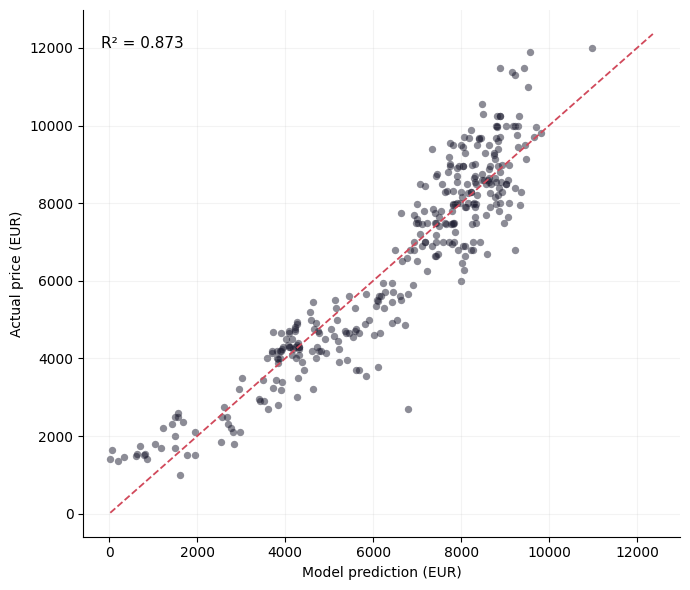

In [5]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')
ax.scatter(df["predicted_price"], df["price_eur"], alpha=0.5, s=28, color='#1a1a2e', linewidths=0)

lims = [df["predicted_price"].min()*0.95, df["price_eur"].max()*1.03]
ax.plot(lims, lims, color='#d1495b', linestyle='--', linewidth=1.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Model prediction (EUR)', fontsize=10)
ax.set_ylabel('Actual price (EUR)', fontsize=10)
ax.grid(alpha=0.15)
ax.text(0.03, 0.95, f'R² = {model.rsquared:.3f}', transform=ax.transAxes, fontsize=11, va='top')

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=180, facecolor='white')
plt.show()

### 4.5 Ранжирование по абсолютному остатку

Ранжирование по проценту отклонения даёт аномально завышенные значения для группы наблюдений с малым `predicted_price`. Это артефакт экстраполяции модели за пределы плотных данных.

**Решение:** ранжирование по абсолютному остатку в евро, с исключением наблюдений при `predicted_price < 2000€`.

In [6]:
usable = df[df["predicted_price"] >= 2000].copy()

print("Топ переоценённых:")
display(usable.sort_values("residual", ascending=False)
        [["car_id","year","mileage_km","price_eur","predicted_price","residual","city"]]
        .head(10).round(1))

print("\nТоп недооценённых:")
display(usable.sort_values("residual", ascending=True)
        [["car_id","year","mileage_km","price_eur","predicted_price","residual","city"]]
        .head(10).round(1))

Топ переоценённых:


,car_id,year,mileage_km,price_eur,predicted_price,residual,city
3,car_004,2021,108792,11490,8883.8,2606.2,Beograd
148,car_149,2022,45776,11899,9567.9,2331.1,Beograd
24,car_025,2021,44306,11390,9146.5,2243.5,Zemun
156,car_157,2022,131993,11290,9216.6,2073.4,Beograd
216,car_217,2020,103346,10550,8478.5,2071.5,Beograd
260,car_261,2022,79652,11490,9429.9,2060.1,Beograd
27,car_028,2018,172646,9398,7341.4,2056.6,Beograd
76,car_077,2018,74334,9550,7741.9,1808.1,Šabac
95,car_096,2020,98000,10299,8500.3,1798.7,Veternik
301,car_302,2018,57000,9500,7812.5,1687.5,Beograd



Топ недооценённых:


,car_id,year,mileage_km,price_eur,predicted_price,residual,city
326,car_327,2016,98000,2700,6790.7,-4090.7,Valjevo
177,car_178,2021,25000,6800,9225.1,-2425.1,Loznica
150,car_151,2015,161000,3790,6106.6,-2316.6,Ruma
278,car_279,2014,121171,3550,5841.4,-2291.4,Kraljevo
147,car_148,2019,116000,5990,7999.6,-2009.6,Novi Beograd
128,car_129,2014,160000,3700,5683.2,-1983.2,Novi Beograd
298,car_299,2020,74940,6690,8594.3,-1904.3,Beograd
249,car_250,2014,180000,3700,5601.7,-1901.7,Sremska Rača
42,car_043,2016,116000,4850,6717.3,-1867.3,Beograd
98,car_099,2019,100000,6290,8064.8,-1774.8,Novi Sad


### 4.6 Надёжность прогноза для редких годов

Годы 2002, 2004, 2006 представлены 1-4 наблюдениями. Надёжность прогноза для них оценивается через ширину доверительного интервала предсказания.

In [7]:
pred = model.get_prediction(X)
summary = pred.summary_frame(alpha=0.05)
df["ci_width"] = summary["mean_ci_upper"] - summary["mean_ci_lower"]

df.groupby("year").agg(n=("year","count"), avg_ci_width=("ci_width","mean")) \
  .sort_values("avg_ci_width", ascending=False).head(6)

,n,avg_ci_width
year,,
2006,1,935.572099
2003,9,591.755914
2004,4,585.482531
2002,1,561.856892
2025,1,485.511744
2007,7,484.820879


Ширина доверительного интервала для 2003, 2004 и 2006 годов существенно выше среднего, что указывает на зависимость точности прогноза от плотности наблюдений в окрестности точки, а не от размера выборки внутри самой группы.

## 5. Вывод

- Год и пробег совместно объясняют 87.3% дисперсии цены: модель обладает высокой объясняющей силой при простой интерпретации коэффициентов
- Получен ранжированный список переоценённых (например, `car_004`: +2606€ к ожидаемой цене) и недооценённых объявлений
- Устойчивость метода подтверждена на увеличенной выборке: коэффициенты сохранили знак и порядок величины при росте n со 155 до 336 (год: +444 → +427, пробег: -0.0045 → -0.0041)

## 6. Практическое применение

- **Продавцам**: уведомление о превышении цены над ожидаемой для года и пробега на N€
- **Покупателям**: маркировка недооценённых объявлений как выгодных предложений

## 7. Ограничения

- Цена объявления: **asking price**, не цена сделки. Систематически завышена относительно фактической. Направление зависимостей (год, пробег → цена) сохраняется, абсолютные значения ориентировочные
- Для годов с малым числом наблюдений (2002, 2004, 2006) точность прогноза снижена (см. 4.6)
- Ранжирование по проценту отклонения непригодно для редких годов (см. 4.5): используется абсолютный остаток
- Данные: срез на конкретную дату (15.07.2026), не панельное наблюдение во времени